## Análise de comércio internacional do Ceará

Esse projeto tem por objetivo a geração de insights sobre movimentações para exportação de carga nos portos do Ceará.

Os dados são de disponibilidade pública e foram obtidos do site www.basedosdados.org.

Os comentários técnicos são feitos dentro de cada célula de código.

### Configurações gerais

In [1]:
#importação das bibliotecas necessárias

import os
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import basedosdados as bd #para conexão com a base de dados
from dotenv import load_dotenv #para ler o arquivo que contém o ID do projeto no google bigquery



In [2]:
#configuração do project ID
load_dotenv()

# O trecho abaixo lê de um outro arquivo o id do projeto. Por questões de segurança dos dados esse arquivo externo não será disponibilizado publicamente.
# Para mais informações sobre como replicar esse projeto consulte o arquivo README.md

project_id = os.getenv("google_id_do_projeto") #SUBSTITUA ESSE CÓDIGO PELO SEU ID PARA REPLICAR O PROJETO


### Principais destinos das exportações cearenses

Aqui entende-se quais são os principais parceiros comerciais das exportações. Essa análise visa identificar se há dependência de um país na economia do Estado.

In [3]:
query = """
SELECT 
    nomeclatura_pais.nome AS destino,  -- destino do produto
    nomeclatura_sh.nome_sh4_portugues AS produto,  -- nome do produto
    SUM(exportacao.valor_fob_dolar) AS valor_USD  -- Valor total das exportações (em dólares)

FROM `basedosdados.br_me_comex_stat.ncm_exportacao` AS exportacao 


-- esses joins são para traduzir o nome dos produtos. Necessário usar tabela intermediária on sh6 para tradução do código sh4
JOIN `basedosdados.br_bd_diretorios_mundo.nomenclatura_comum_mercosul` AS nomeclatura_mercosul_intermediario  
  ON exportacao.id_ncm = nomeclatura_mercosul_intermediario.id_ncm
JOIN `basedosdados.br_bd_diretorios_mundo.sistema_harmonizado` AS nomeclatura_sh 
  ON nomeclatura_mercosul_intermediario.id_sh6 = nomeclatura_sh.id_sh6

-- esse join é para traduzir a UF de origem e permitir selecionar apenas o estado do Ceará
LEFT JOIN (SELECT DISTINCT sigla,nome  FROM `basedosdados.br_bd_diretorios_brasil.uf`) AS diretorio_sigla_uf_ncm 
  ON exportacao.sigla_uf_ncm = diretorio_sigla_uf_ncm.sigla

-- esse join é para traduzir o nome dos países
JOIN `basedosdados.br_bd_diretorios_mundo.pais` AS nomeclatura_pais   
  ON exportacao.sigla_pais_iso3 = nomeclatura_pais.sigla_pais_iso3   

-- esse join serve para identificar a via de exportação e permitir a seleção apenas da via marítima
LEFT JOIN `basedosdados.br_me_comex_stat.dicionario` AS dic  
  ON exportacao.id_via = dic.chave
  AND dic.nome_coluna = 'id_via'
  AND dic.id_tabela = 'ncm_exportacao'

WHERE exportacao.ano BETWEEN 2015 AND 2025 -- limitador de 10 anos

GROUP BY produto, destino, diretorio_sigla_uf_ncm.nome, dic.valor

HAVING 
  diretorio_sigla_uf_ncm.nome = 'Ceará' -- limitador de exportações apenas do estado do Ceará 
  AND dic.valor = 'Maritima'  -- limitador de exportações via marítima

ORDER BY valor_USD DESC  -- Para organizar por ordem de valor total de vendas
"""

df = bd.read_sql(
    query,  # a query criada acima
    billing_project_id=project_id  # o id do projeto
)

Downloading: 100%|██████████|


In [4]:
# somar os valores de cada país para se ter um panorama geral
df_paises = df.groupby("destino")["valor_USD"].sum().reset_index()

# ordenar por valor total
df_paises=df_paises.sort_values(by="valor_USD", ascending=False) # ascending False para organizar por ordem decrescente

# formatar os valores do número para melhor visualização
df_paises["valor_USD"] = df_paises["valor_USD"] / 1_000_000


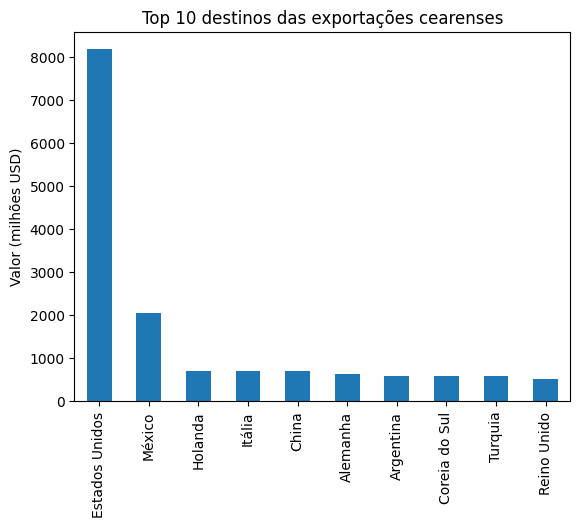

In [5]:
# plotar resultado em gráfico
ax = df_paises.head(10).plot(
    kind="bar",
    x="destino",
    y="valor_USD",
    legend=False
)

plt.title("Top 10 destinos das exportações cearenses")
plt.xlabel("")
plt.ylabel("Valor (milhões USD)")

plt.show()

Nota-se um claro destaque dos Estados Unidos como principal destino das exportações cearenses. Essa dominância sobre os demais países pode ser uma vulnerabilidade, uma vez que qualquer alteração no regime de comércio com esse país tem um grande impacto na economia estadual.

Devido ao resultado obtido através do gráfico, é valida uma investigação mais aprofundada sobre o que compõe esse volume de importações para os Estados Unidos.

In [6]:
df_us = df[df["destino"]=="Estados Unidos"].copy() # novo df para selecionar apenas as exportações para EUA

df_us.head()

,destino,produto,valor_USD
0,Estados Unidos,Produtos semimanufacturados de ferro ou aço nã...,4078641563
2,Estados Unidos,"Outras ligas de aço, em lingotes ou outras for...",943806240
5,Estados Unidos,Partes reconhecíveis como destinadas às máquin...,444092779
6,Estados Unidos,Sumos de frutas (incluídos os mostos de uvas) ...,422288920
8,Estados Unidos,"Cocos, castanha do Brasil e castanha de caju, ...",363132063


O resultado acima indica dominância de dois produtos nas exportações direcionadas aos Estados Unidos. Abaixo um gráfico para destacar essa distância em relação aos demais produtos.

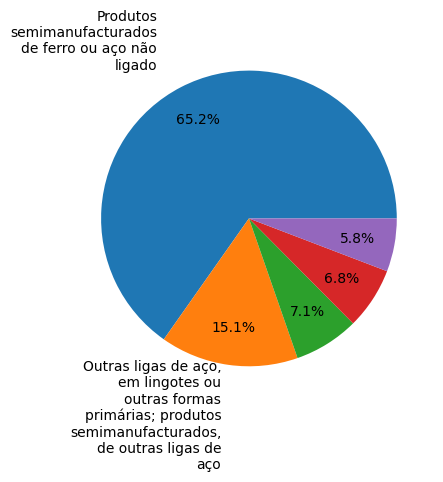

In [7]:

rotulos = df_us.head(2)["produto"].tolist() #pegando apenas os dois primeiros produtos com maior parcela
rotulos = [textwrap.fill(i, width =20) for i in rotulos] # para permitir quebrar as linhas dos nomes dos produtos
rotulos = rotulos + (['']*(len(df_us['produto'].head())-2)) # popular a lista de rotulos com string vazia para ter a mesma quantidade de elementos em relação ao gráfico

plt.pie( # gráfico de pizza
    x=df_us["valor_USD"].head(), 
    labels= rotulos,
    labeldistance=1.35, # controla distância do rótulo de dados
    textprops={'fontsize': 10}, # controla tamanho da fonte do rótulo de dados
    autopct="%1.1f%%", # inclui porcentagem de cada categoria
    pctdistance=0.75 # controla posição das porcentagens
)

plt.xlabel("")
plt.ylabel("")

plt.show()


Nota-se fortes valores de exportação de produtos siderúrgicos, dominando quase 70% das transações para os Estados Unidos.

### Diferenças de carga entre os portos

O foco agora é entender as particularidades de cada porto. O estado do Ceará possui 2 portos, e essa análise vem identificar quais são as principais cargas de cada um. A finalidade é fornecer base técnica para decisões logísticas visando direcionar corretamente cada tipo de carga, aumentando assim a eficiência.

In [8]:
# falta na tabela -> nome do municipio, produto, movimentação de carga (toneladas), ano, via maritima
# basedosdados.br_bd_diretorios_brasil.unidade_receita_federal

### Análise de sazonalidade de cargas

Essa seção analisa a movimentação de cargas sazonais, principalmente frutas e derivados. O objetivo é destacar padrões que ajudem no planejamento logístico, evitando assim gargalos e consequentes prejuízos.

### Os parceiros emergentes

Quais países mais cresceram no total de exportações? Identificar esses novos destinos para as mercadorias estaduais tem grande valor. Por isso, esse trecho busca identificar países que tiveram crescimento econômico nas movimentações, fornecendo assim dados sobre a expansão da economia estadual e podendo orientar políticas públicas e acordos internacionais. Como a intenção é analisar crescimento recente, serão considerados apenas os anos completos de 2022 e 2024.

In [9]:


query = """ 
SELECT
    nomeclatura_pais.nome AS destino,  -- destino do produto
    SUM(IF(ano=2022, exportacao.valor_fob_dolar,0)) AS valor_2022,
    SUM(IF(ano=2024, exportacao.valor_fob_dolar,0)) AS valor_2024,
    SUM(exportacao.valor_fob_dolar) AS valor_total

FROM `basedosdados.br_me_comex_stat.ncm_exportacao` AS exportacao

-- esse join é para traduzir a UF de origem e permitir selecionar apenas o estado do Ceará
LEFT JOIN (SELECT DISTINCT sigla,nome  FROM `basedosdados.br_bd_diretorios_brasil.uf`) AS diretorio_sigla_uf_ncm 
  ON exportacao.sigla_uf_ncm = diretorio_sigla_uf_ncm.sigla

-- esse join é para traduzir o nome dos países
JOIN `basedosdados.br_bd_diretorios_mundo.pais` AS nomeclatura_pais   
  ON exportacao.sigla_pais_iso3 = nomeclatura_pais.sigla_pais_iso3

-- esse join serve para identificar a via de exportação e permitir a seleção apenas da via marítima
LEFT JOIN `basedosdados.br_me_comex_stat.dicionario` AS dic  
  ON exportacao.id_via = dic.chave
  AND dic.nome_coluna = 'id_via'
  AND dic.id_tabela = 'ncm_exportacao'

WHERE exportacao.ano IN (2022, 2024) -- limitador de 3 anos
AND diretorio_sigla_uf_ncm.nome = 'Ceará' -- limitador de exportações apenas do estado do Ceará 
AND dic.valor = 'Maritima'  -- limitador de exportações via marítima

GROUP BY  destino -- juntando todos os resultados de um país em uma única linha

ORDER BY valor_total DESC  -- países com maior valor em exportação primeiro
"""

df_4 = bd.read_sql(
    query,  # a query criada acima
    billing_project_id=project_id  # o id do projeto
)

df_4.head()

Downloading: 100%|██████████|


,destino,valor_2022,valor_2024,valor_total
0,Estados Unidos,586368259,648049880,1234418139
1,México,569571254,57415937,626987191
2,Espanha,139656547,19162712,158819259
3,Itália,104473220,41481844,145955064
4,Holanda,71565028,62532100,134097128


In [ ]:
#tratamento de valores e criação de indicadores de crescimento

# Existem países que são novos parceiros comerciais, tendo valores de exportação em 2024 mas não em 2022.
# Esses países são excluídos da análise para que se possa criar corretamente o porcentual de crescimento.
# Se mantidos, esses países causariam erro de valor infinito, o que não permitira a visualização do crescimento em gráfico.


#aqui se removem os países que não tinham valor de exportação em 2022.
df_4 = df_4.drop(df_4[df_4["valor_2022"] == 0].index)


# aqui se cria a coluna com o % de crescimento como a relação entre o valor de exportações em 2024 e em 2022.
df_4['crescimento (%)'] = ((round(df_4['valor_2024'] / df_4['valor_2022'], 3))-1)*100 # razão arredondada com 2 casa decimais. Continua como decimal mas pode ser lida como porcentagem.


# ordenar o dataset em ordem decrescente de % de crescimento
df_4.sort_values(by="crescimento (%)",
                ascending=False, #ordem decrescente
                inplace=True
                )

In [15]:
df_4.head(10)

,destino,valor_2022,valor_2024,valor_total,crescimento (%)
66,São Vicente e Granadinas,19411,1335610,1355021,6780.7
79,Letónia,12573,677176,689749,5286.0
116,Belize,8141,118305,126446,1353.2
15,Coreia do Sul,2869479,34375443,37244922,1098.0
100,Maldivas,36361,306850,343211,743.9
71,Malásia,137462,975191,1112653,609.4
39,Egito,655722,4122232,4777954,528.7
92,Noruega,70765,433199,503964,512.2
97,Paraguai,63953,288377,352330,350.9
22,Venezuela,2814563,11536429,14350992,309.9


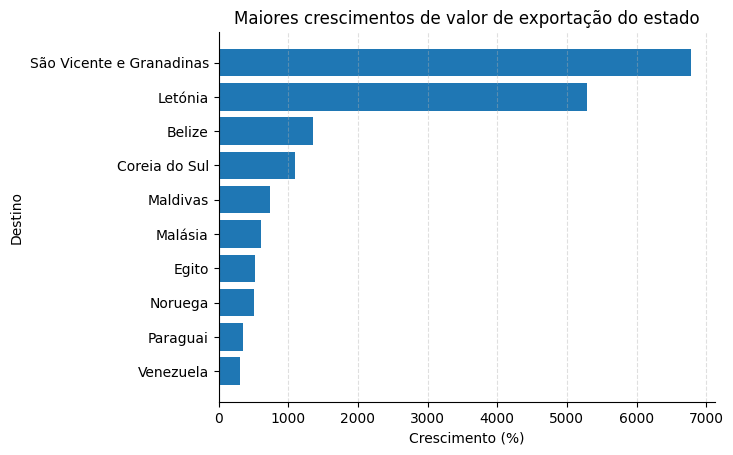

In [ ]:
# plotar gráfico de barras horizontais
plt.barh(
    df_4['destino'].head(10),
    df_4['crescimento (%)'].head(10)
)

plt.gca().invert_yaxis() # necessário para a correta ordem decrescente dos valores.

# remover as linhas de cima e da direita da "caixa" em que o gráfico é criado
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x', linestyle='--', alpha=0.4) # adicionar o grid para melhor visuzaliação
plt.title("Maiores crescimentos de valor de exportação do estado")
plt.xlabel("Crescimento (%)")
plt.ylabel("Destino")
plt.show()

Nesse ponto nota-se a diversificação das movimentações de exportação do estado. Entre os maiores crescimentos comerciais tem-se desde pequenas economias locais até grande potencias econômicas mundiais. Cabe nota também que esses parceiros emergentes estão por todo o planeta, tendo representantes de todos os continentes entre os 10 maiores crescimentos.